In [1]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.utils import shuffle
from imblearn.over_sampling import SMOTE
import lazypredict
from lazypredict.Supervised import LazyClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import ConfusionMatrixDisplay,confusion_matrix, accuracy_score, classification_report
from sklearn.metrics import roc_curve, auc, roc_auc_score



In [2]:
df = pd.read_csv("stroke.csv")
df.head()

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,Male,67.00,0,1,Yes,Private,Urban,228.69,36.60,formerly smoked,1
1,51676,Female,61.00,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
2,31112,Male,80.00,0,1,Yes,Private,Rural,105.92,32.50,never smoked,1
3,60182,Female,49.00,0,0,Yes,Private,Urban,171.23,34.40,smokes,1
4,1665,Female,79.00,1,0,Yes,Self-employed,Rural,174.12,24.00,never smoked,1


In [3]:
df.isna().sum()

id                     0
gender                 0
age                    0
hypertension           0
heart_disease          0
ever_married           0
work_type              0
Residence_type         0
avg_glucose_level      0
bmi                  201
smoking_status         0
stroke                 0
dtype: int64

In [4]:
df = df.dropna()
df = df.drop("id",axis=1)
df['ever_married'] = df['ever_married'].map( 
                   {'Yes':1 ,'No':0})
df['ever_married'].value_counts()

ever_married
1    3204
0    1705
Name: count, dtype: int64

In [5]:
df.isna().sum()                                             

gender               0
age                  0
hypertension         0
heart_disease        0
ever_married         0
work_type            0
Residence_type       0
avg_glucose_level    0
bmi                  0
smoking_status       0
stroke               0
dtype: int64

In [6]:
df['gender'].value_counts()

gender
Female    2897
Male      2011
Other        1
Name: count, dtype: int64

In [7]:
df = df[df['gender'] != 'Other']
df['gender'].value_counts()

gender
Female    2897
Male      2011
Name: count, dtype: int64

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 4908 entries, 0 to 5109
Data columns (total 11 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   gender             4908 non-null   object 
 1   age                4908 non-null   float64
 2   hypertension       4908 non-null   int64  
 3   heart_disease      4908 non-null   int64  
 4   ever_married       4908 non-null   int64  
 5   work_type          4908 non-null   object 
 6   Residence_type     4908 non-null   object 
 7   avg_glucose_level  4908 non-null   float64
 8   bmi                4908 non-null   float64
 9   smoking_status     4908 non-null   object 
 10  stroke             4908 non-null   int64  
dtypes: float64(3), int64(4), object(4)
memory usage: 460.1+ KB


In [9]:
df['stroke'].value_counts()               

stroke
0    4699
1     209
Name: count, dtype: int64

In [10]:
numerical_df = df[['age','hypertension','heart_disease','ever_married','avg_glucose_level','bmi','stroke']]

In [11]:
numerical_df.shape

(4908, 7)

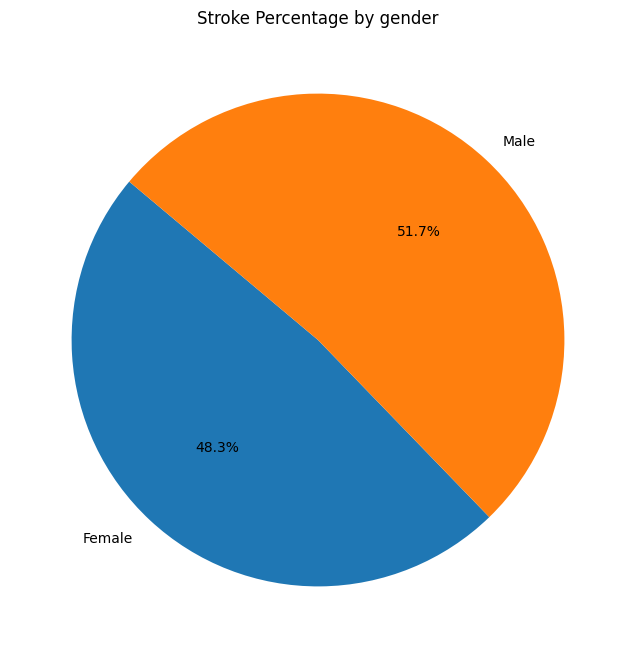

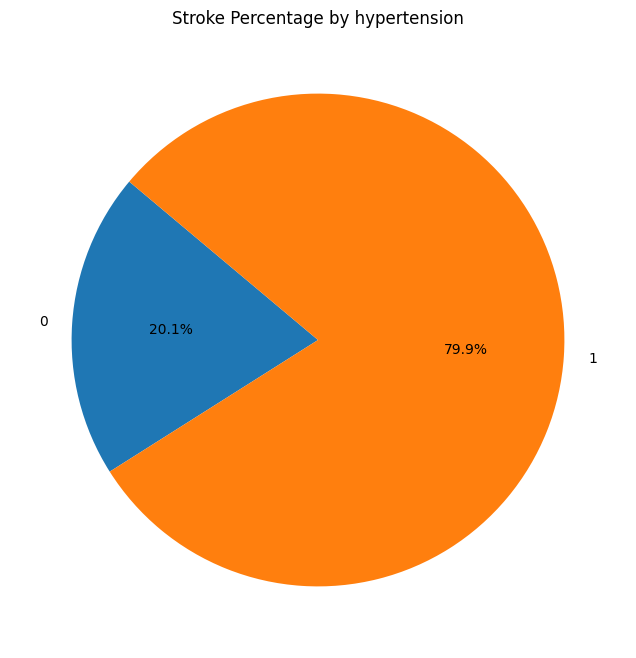

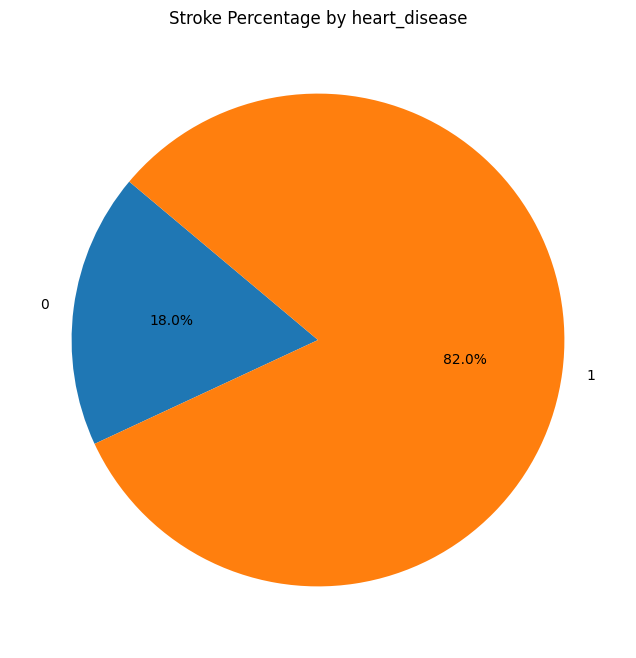

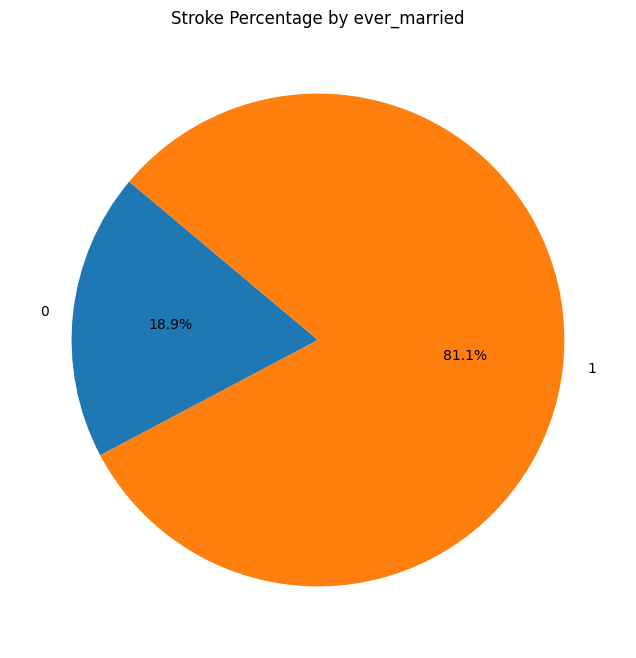

In [12]:
ColumnsForCountPlot = ['gender','hypertension','heart_disease','ever_married']
for column in ColumnsForCountPlot:
    stroke_percentages = df.groupby(column)['stroke'].mean() * 100
    plt.figure(figsize=(8, 8))
    plt.pie(stroke_percentages, labels=stroke_percentages.index, autopct='%1.1f%%', startangle=140)
    plt.title(f'Stroke Percentage by {column}')
    plt.show()

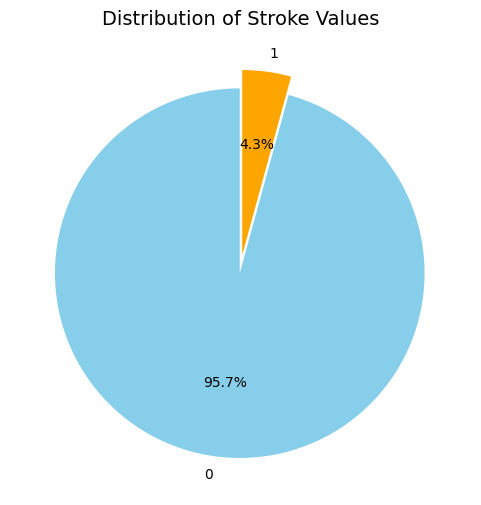

In [13]:
# Tính tần suất (số lượng) của từng giá trị trong cột 'stroke'
target_counts = df['stroke'].value_counts()

# Vẽ biểu đồ tròn
plt.figure(figsize=(6, 6))
plt.pie(
    target_counts, 
    labels=target_counts.index, 
    autopct='%1.1f%%', 
    startangle=90, 
    colors=['skyblue', 'orange'], 
    explode=[0.05] * len(target_counts)  # Tách nhẹ các phần
)

# Tùy chỉnh tiêu đề
plt.title('Distribution of Stroke Values', fontsize=14)
plt.show()

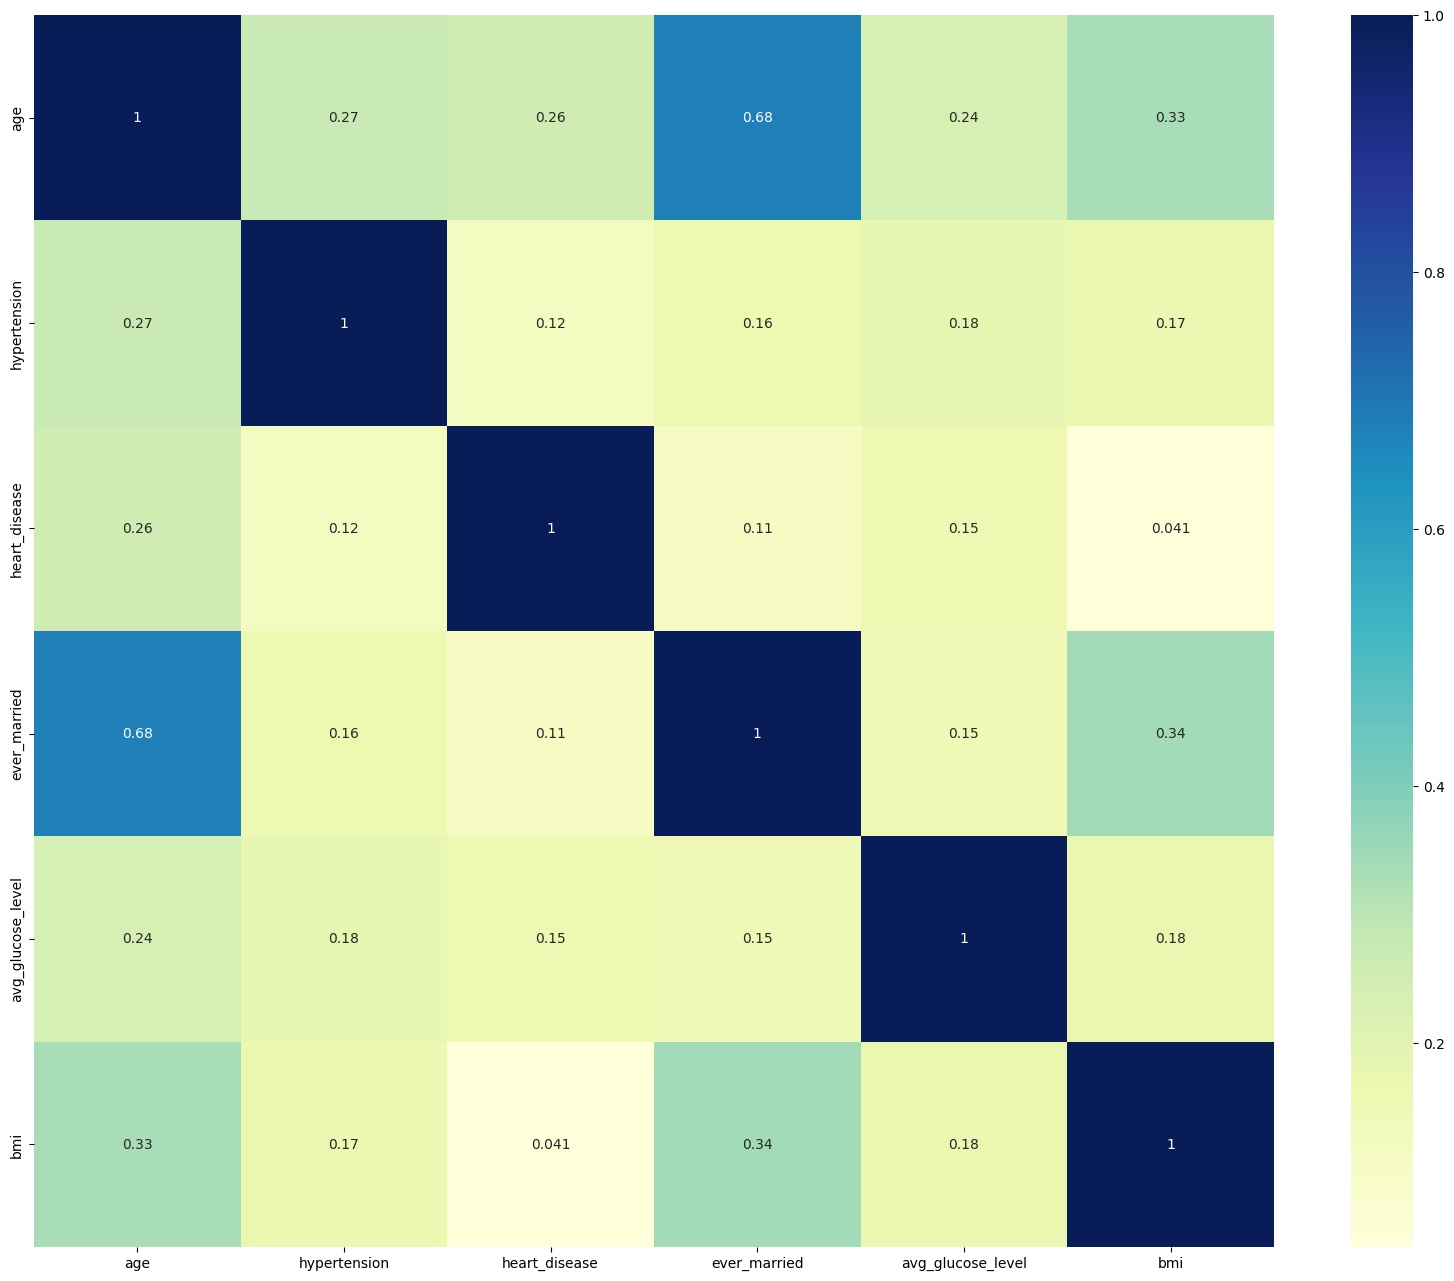

In [14]:
numeric_df = df.drop('stroke', axis=1).select_dtypes(include=['number'])
corr = numeric_df.corr()
plt.figure(figsize=(20, 16))
sns.heatmap(corr, cmap="YlGnBu", annot=True)
plt.show()

In [15]:
df = pd.get_dummies(df).astype(int)
df.head()

,age,hypertension,heart_disease,ever_married,avg_glucose_level,bmi,stroke,gender_Female,gender_Male,work_type_Govt_job,work_type_Never_worked,work_type_Private,work_type_Self-employed,work_type_children,Residence_type_Rural,Residence_type_Urban,smoking_status_Unknown,smoking_status_formerly smoked,smoking_status_never smoked,smoking_status_smokes
0,67,0,1,1,228,36,1,0,1,0,0,1,0,0,0,1,0,1,0,0
2,80,0,1,1,105,32,1,0,1,0,0,1,0,0,1,0,0,0,1,0
3,49,0,0,1,171,34,1,1,0,0,0,1,0,0,0,1,0,0,0,1
4,79,1,0,1,174,24,1,1,0,0,0,0,1,0,1,0,0,0,1,0
5,81,0,0,1,186,29,1,0,1,0,0,1,0,0,0,1,0,1,0,0


In [16]:
x = df.drop("stroke",axis=1)
y = df.stroke

In [17]:
smote = SMOTE(sampling_strategy="minority")
x_smote , y_smote = smote.fit_resample(x,y)   
y_smote.value_counts()            

stroke
1    4699
0    4699
Name: count, dtype: int64

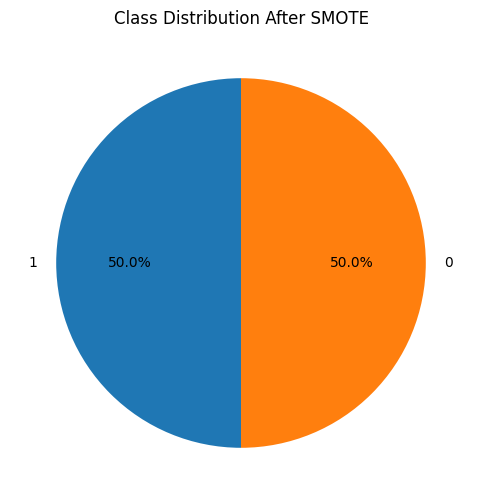

In [18]:
# Lấy số lượng các lớp trong y_smote
class_counts = y_smote.value_counts()

# Vẽ biểu đồ tròn
plt.figure(figsize=(6, 6))
plt.pie(class_counts, labels=class_counts.index, autopct='%1.1f%%', startangle=90)
plt.title('Class Distribution After SMOTE')
plt.show()

In [19]:


# Áp dụng SMOTE để tạo mẫu dữ liệu cân bằng
smote = SMOTE(sampling_strategy="minority")
x_smote, y_smote = smote.fit_resample(x, y)

# Chia dữ liệu thành tập huấn luyện và kiểm tra
X_train, X_test, y_train, y_test = train_test_split(x_smote, y_smote, test_size=0.2, random_state=42, stratify=y_smote)

# Chuẩn hóa dữ liệu
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Shuffle lại dữ liệu sau khi chuẩn hóa
X_train, y_train = shuffle(X_train, y_train, random_state=42)
X_test, y_test = shuffle(X_test, y_test, random_state=42)

# Xem lại kết quả
print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")

X_train shape: (7518, 19)
X_test shape: (1880, 19)


In [20]:
y_train.value_counts() ,y_test.value_counts()

(stroke
 1    3759
 0    3759
 Name: count, dtype: int64,
 stroke
 1    940
 0    940
 Name: count, dtype: int64)

In [21]:


clf = LazyClassifier(verbose=0,ignore_warnings=True, custom_metric=None)
models,predictions = clf.fit(X_train, X_test, y_train, y_test)

print(models)


100%|██████████| 31/31 [00:10<00:00,  2.98it/s]

[LightGBM] [Info] Number of positive: 3759, number of negative: 3759
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000391 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 392
[LightGBM] [Info] Number of data points in the train set: 7518, number of used features: 18
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
                               Accuracy  Balanced Accuracy  ROC AUC  F1 Score  \
Model                                                                           
RandomForestClassifier             0.97               0.98     0.98      0.97   
ExtraTreesClassifier               0.97               0.97     0.97      0.97   
LGBMClassifier                     0.97               0.97     0.97      0.97   
BaggingClassifier                  0.97               0.97     0.97      0.97   
KNeighborsClass

In [22]:


classifier = RandomForestClassifier(random_state=42)

# Định nghĩa tham số để tối ưu hóa
param_grid = {
    'max_depth': [None, 10, 20, 30],
    'max_features': ['sqrt', 'log2'],  # Không sử dụng 'auto'
    'min_samples_leaf': [1, 2, 4],
    'min_samples_split': [2, 5, 10],
    'n_estimators': [50, 100, 200]
}

# Thiết lập GridSearchCV
grid_search = GridSearchCV(estimator=classifier, param_grid=param_grid, cv=5, n_jobs=-1, error_score='raise')

# Huấn luyện mô hình
grid_search.fit(X_train, y_train)

print("Best Parameters:", grid_search.best_params_)
print("Best Cross-validation Accuracy:", grid_search.best_score_)

Best Parameters: {'max_depth': 20, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 100}
Best Cross-validation Accuracy: 0.9749939836638779


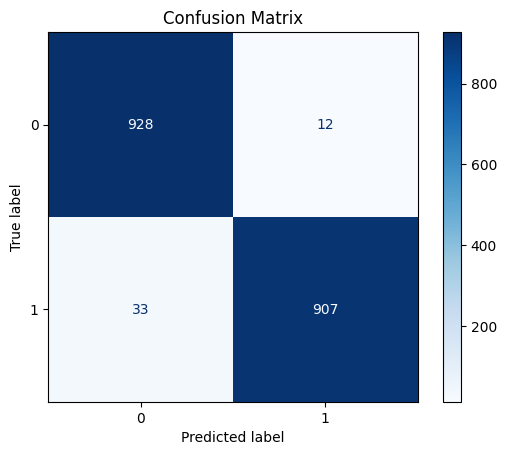

In [23]:
best_model = grid_search.best_estimator_

y_pred_best = best_model.predict(X_test)

# Hiển thị ma trận nhầm lẫn
cm = confusion_matrix(y_test, y_pred_best)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix")
plt.show()

In [24]:
# Dự đoán và đánh giá mô hình với tham số tốt nhất
best_model = grid_search.best_estimator_
y_pred = best_model.predict(X_test)

# Đánh giá mô hình
accuracy_for_test = accuracy_score(y_test, y_pred)
print('Accuracy for test set with best parameters = {:.2f}'.format(accuracy_for_test))
print('\nClassification Report:\n', classification_report(y_test, y_pred))

# Optional: Confusion Matrix
confusion_mat = confusion_matrix(y_test, y_pred)
print('\nConfusion Matrix:\n', confusion_mat)

Accuracy for test set with best parameters = 0.98

Classification Report:
               precision    recall  f1-score   support

           0       0.97      0.99      0.98       940
           1       0.99      0.96      0.98       940

    accuracy                           0.98      1880
   macro avg       0.98      0.98      0.98      1880
weighted avg       0.98      0.98      0.98      1880


Confusion Matrix:
 [[928  12]
 [ 33 907]]


AUC = 1.00


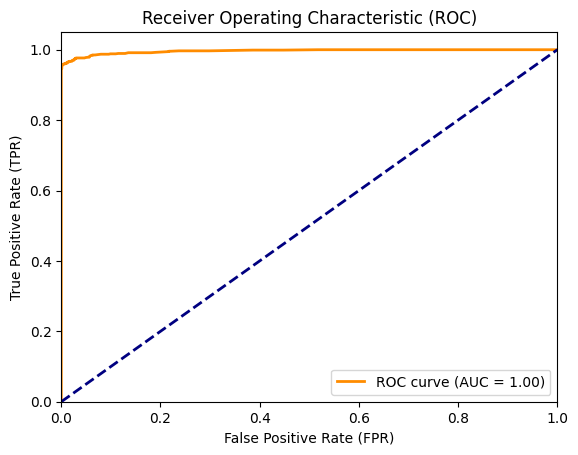

In [25]:

# Giả sử y_test là nhãn thực tế và y_pred_prob là xác suất dự đoán của mô hình (không phải nhãn)
y_pred_prob = best_model.predict_proba(X_test)[:, 1]  # Lấy xác suất của lớp dương

# Tính toán ROC Curve
fpr, tpr, thresholds = roc_curve(y_test, y_pred_prob)

# Tính toán AUC
roc_auc = auc(fpr, tpr)
print('AUC = {:.2f}'.format(roc_auc))

# Vẽ đường ROC Curve
plt.figure()
plt.plot(fpr, tpr, color='darkorange', lw=2, label='ROC curve (AUC = {:.2f})'.format(roc_auc))
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')  # Đường chéo thể hiện dự đoán ngẫu nhiên
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (FPR)')
plt.ylabel('True Positive Rate (TPR)')
plt.title('Receiver Operating Characteristic (ROC)')
plt.legend(loc="lower right")
plt.show()


In [26]:
import pickle
with open('stroke.pkl','wb') as file:
    pickle.dump(grid_search, file)